In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
import os

FIG_DIR = "/content/drive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5"
TAB_DIR = "/content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5"

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

print("Figure dir:", FIG_DIR)
print("Table dir:", TAB_DIR)

Figure dir: /content/drive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5
Table dir: /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5


In [55]:
# ============================================================
# CELL 02 — Imports
# ============================================================

import os
import json
import math
import time
import copy
import random
import warnings
from dataclasses import dataclass
from typing import Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Dirichlet

warnings.filterwarnings("ignore")

In [56]:
# ============================================================
# CELL 03 — Project config
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis_rl_trading_final"

DATA_PROCESSED_DIR = f"{PROJECT_ROOT}/data_processed"
OUTPUTS_MODEL_DIR = f"{PROJECT_ROOT}/outputs/model_outputs"
OUTPUTS_REWARD_DIR = f"{PROJECT_ROOT}/outputs/reward_comparison"
CONFIGS_DIR = f"{PROJECT_ROOT}/configs"

for path in [
    DATA_PROCESSED_DIR,
    OUTPUTS_MODEL_DIR,
    OUTPUTS_REWARD_DIR,
    CONFIGS_DIR,
]:
    os.makedirs(path, exist_ok=True)

with open(f"{CONFIGS_DIR}/master_config.json", "r") as f:
    master_cfg = json.load(f)

with open(f"{CONFIGS_DIR}/feature_columns.json", "r") as f:
    feature_cfg = json.load(f)

ASSETS = master_cfg["assets"]
LOOKBACK = master_cfg["lookback"]
SEED = master_cfg["seed"]
FEATURE_COLS = feature_cfg["feature_columns"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TRANSACTION_COST = 0.001

# Transformer config (must match notebook 06)
D_MODEL = 128
NHEAD = 4
NUM_LAYERS = 2
FF_DIM = 256
DROPOUT = 0.1

# PPO config (must match notebook 06)
LR = 3e-4
WEIGHT_DECAY = 1e-5

GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_EPS = 0.2
VALUE_COEF = 0.5
ENTROPY_COEF = 0.001
MAX_GRAD_NORM = 0.5

TRAIN_EPOCHS = 60
PPO_UPDATES_PER_EPOCH = 10
MINIBATCH_SIZE = 128

DIRICHLET_CONC_MIN = 5.0
DIRICHLET_CONC_MAX = 200.0

RUN_NAME_NO_COST = "transformer_ppo_nocost_5y"
MODEL_DIR_NO_COST = f"{OUTPUTS_MODEL_DIR}/{RUN_NAME_NO_COST}"
MODEL_DIR_COST_AWARE = f"{OUTPUTS_MODEL_DIR}/transformer_ppo_final_5y"

os.makedirs(MODEL_DIR_NO_COST, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("DEVICE:", DEVICE)
print("MODEL_DIR_COST_AWARE:", MODEL_DIR_COST_AWARE)
print("MODEL_DIR_NO_COST:", MODEL_DIR_NO_COST)

DEVICE: cpu
MODEL_DIR_COST_AWARE: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_final_5y
MODEL_DIR_NO_COST: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_nocost_5y


In [57]:
# ============================================================
# CELL 04 — Load env-ready data
# ============================================================

env_ready = np.load(f"{DATA_PROCESSED_DIR}/env_ready_5y.npz", allow_pickle=True)

X_train = env_ready["X_train"].astype(np.float32)
y_train = env_ready["y_train"].astype(np.float32)
dates_train = env_ready["dates_train"]

X_val = env_ready["X_val"].astype(np.float32)
y_val = env_ready["y_val"].astype(np.float32)
dates_val = env_ready["dates_val"]

X_test = env_ready["X_test"].astype(np.float32)
y_test = env_ready["y_test"].astype(np.float32)
dates_test = env_ready["dates_test"]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (717, 20, 5, 13) y_train: (717, 5)
X_val: (250, 20, 5, 13) y_val: (250, 5)
X_test: (251, 20, 5, 13) y_test: (251, 5)


In [58]:
# ============================================================
# CELL 05 — PortfolioEnv
# ============================================================

@dataclass
class EnvStepResult:
    next_state: Optional[np.ndarray]
    reward: float
    done: bool
    info: Dict


class PortfolioEnv:
    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        dates: np.ndarray,
        transaction_cost: float = 0.001,
        reward_mode: str = "cost_aware",
    ):
        assert reward_mode in ["cost_aware", "no_cost"]

        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        self.dates = dates
        self.transaction_cost = float(transaction_cost)
        self.reward_mode = reward_mode

        self.n_steps = self.X.shape[0]
        self.lookback = self.X.shape[1]
        self.n_assets = self.X.shape[2]
        self.n_features = self.X.shape[3]

        self.reset()

    def reset(self) -> np.ndarray:
        self.t = 0
        self.prev_weights = np.ones(self.n_assets, dtype=np.float32) / self.n_assets
        self.portfolio_value = 1.0
        self.done = False
        return self.X[self.t]

    def _sanitize_action(self, action: np.ndarray) -> np.ndarray:
        action = np.asarray(action, dtype=np.float32).reshape(-1)
        if len(action) != self.n_assets:
            raise ValueError(f"Action length {len(action)} != n_assets {self.n_assets}")

        action = np.clip(action, 1e-8, None)
        action = action / action.sum()
        return action.astype(np.float32)

    def step(self, action: np.ndarray) -> EnvStepResult:
        if self.done:
            raise RuntimeError("Episode already done. Call reset().")

        w_t = self._sanitize_action(action)
        r_t = self.y[self.t]

        portfolio_simple_return = float(np.dot(w_t, r_t))
        turnover = float(np.sum(np.abs(w_t - self.prev_weights)))
        trading_cost = self.transaction_cost * turnover

        portfolio_simple_return = max(portfolio_simple_return, -0.999999)

        reward_no_cost = math.log(1.0 + portfolio_simple_return)
        reward_cost_aware = reward_no_cost - trading_cost
        reward = reward_cost_aware if self.reward_mode == "cost_aware" else reward_no_cost

        gross_value_next = self.portfolio_value * (1.0 + portfolio_simple_return)
        net_value_next = gross_value_next * (1.0 - trading_cost)

        self.portfolio_value = float(net_value_next)
        self.prev_weights = w_t.copy()

        info = {
            "date": str(self.dates[self.t]),
            "weights": w_t.copy(),
            "asset_returns": r_t.copy(),
            "portfolio_simple_return": portfolio_simple_return,
            "reward_no_cost": reward_no_cost,
            "reward_cost_aware": reward_cost_aware,
            "turnover": turnover,
            "trading_cost": trading_cost,
            "portfolio_value": self.portfolio_value,
        }

        self.t += 1
        self.done = (self.t >= self.n_steps)
        next_state = None if self.done else self.X[self.t]

        return EnvStepResult(
            next_state=next_state,
            reward=float(reward),
            done=self.done,
            info=info,
        )

In [59]:
# ============================================================
# CELL 06 — Transformer model
# ============================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        l = x.size(1)
        return x + self.pe[:, :l, :]


class TransformerEncoderState(nn.Module):
    def __init__(
        self,
        lookback: int,
        n_assets: int,
        n_features: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        ff_dim: int,
        dropout: float,
    ):
        super().__init__()

        self.input_dim = n_assets * n_features
        self.input_proj = nn.Linear(self.input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=lookback + 5)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers,
        )

        self.post = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, l, n, f = x.shape
        x = x.reshape(b, l, n * f)
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        h = self.transformer(x)
        h_last = h[:, -1, :]
        h_last = self.post(h_last)
        return h_last


class TransformerActorCritic(nn.Module):
    def __init__(
        self,
        lookback: int,
        n_assets: int,
        n_features: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        ff_dim: int,
        dropout: float,
        conc_min: float = 5.0,
        conc_max: float = 200.0,
    ):
        super().__init__()

        self.n_assets = n_assets
        self.conc_min = conc_min
        self.conc_max = conc_max

        self.encoder = TransformerEncoderState(
            lookback=lookback,
            n_assets=n_assets,
            n_features=n_features,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            ff_dim=ff_dim,
            dropout=dropout,
        )

        self.actor_logits = nn.Linear(d_model, n_assets)
        self.actor_concentration = nn.Linear(d_model, 1)
        self.critic = nn.Linear(d_model, 1)

    def _get_shared(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

    def get_policy_dist(self, x: torch.Tensor):
        h = self._get_shared(x)

        logits = self.actor_logits(h)
        mean_weights = torch.softmax(logits, dim=-1)

        raw_conc = self.actor_concentration(h)
        conc_scalar = torch.sigmoid(raw_conc)
        conc_scalar = self.conc_min + (self.conc_max - self.conc_min) * conc_scalar
        conc_scalar = conc_scalar.squeeze(-1)

        alpha = mean_weights * conc_scalar.unsqueeze(-1)
        alpha = torch.clamp(alpha, min=1e-4)

        dist = Dirichlet(alpha)
        return dist, mean_weights, alpha

    def get_value(self, x: torch.Tensor) -> torch.Tensor:
        h = self._get_shared(x)
        v = self.critic(h).squeeze(-1)
        return v

    def act(self, x: torch.Tensor):
        dist, mean_weights, alpha = self.get_policy_dist(x)
        action = dist.rsample()
        log_prob = dist.log_prob(action)
        value = self.get_value(x)
        entropy = dist.entropy()
        return action, log_prob, value, entropy, mean_weights, alpha

    def act_deterministic(self, x: torch.Tensor):
        dist, mean_weights, alpha = self.get_policy_dist(x)
        value = self.get_value(x)
        return mean_weights, value, alpha

In [60]:
# ============================================================
# CELL 07 — PPO helpers
# ============================================================

def compute_gae(
    rewards: np.ndarray,
    values: np.ndarray,
    dones: np.ndarray,
    gamma: float,
    gae_lambda: float,
):
    T = len(rewards)
    advantages = np.zeros(T, dtype=np.float32)
    last_adv = 0.0

    for t in reversed(range(T)):
        next_value = 0.0 if t == T - 1 else values[t + 1]
        next_nonterminal = 1.0 - dones[t]

        delta = rewards[t] + gamma * next_value * next_nonterminal - values[t]
        last_adv = delta + gamma * gae_lambda * next_nonterminal * last_adv
        advantages[t] = last_adv

    returns = advantages + values
    return advantages.astype(np.float32), returns.astype(np.float32)


def normalize_advantages(adv: torch.Tensor) -> torch.Tensor:
    return (adv - adv.mean()) / (adv.std() + 1e-8)


def collect_rollout(model: nn.Module, env: PortfolioEnv, device: str):
    model.eval()

    states = []
    actions = []
    log_probs = []
    rewards = []
    dones = []
    values = []
    infos = []

    state = env.reset()

    while True:
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            action_t, log_prob_t, value_t, entropy_t, mean_weights_t, alpha_t = model.act(state_tensor)

        action = action_t.squeeze(0).cpu().numpy()
        result = env.step(action)

        states.append(state)
        actions.append(action)
        log_probs.append(float(log_prob_t.item()))
        rewards.append(float(result.reward))
        dones.append(float(result.done))
        values.append(float(value_t.item()))
        infos.append(result.info)

        if result.done:
            break

        state = result.next_state

    rollout = {
        "states": np.asarray(states, dtype=np.float32),
        "actions": np.asarray(actions, dtype=np.float32),
        "log_probs": np.asarray(log_probs, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32),
        "dones": np.asarray(dones, dtype=np.float32),
        "values": np.asarray(values, dtype=np.float32),
        "infos": infos,
    }

    advantages, returns = compute_gae(
        rewards=rollout["rewards"],
        values=rollout["values"],
        dones=rollout["dones"],
        gamma=GAMMA,
        gae_lambda=GAE_LAMBDA,
    )

    rollout["advantages"] = advantages
    rollout["returns"] = returns
    return rollout


def ppo_update(model, optimizer, rollout, device: str):
    model.train()

    states = torch.tensor(rollout["states"], dtype=torch.float32, device=device)
    actions = torch.tensor(rollout["actions"], dtype=torch.float32, device=device)
    old_log_probs = torch.tensor(rollout["log_probs"], dtype=torch.float32, device=device)
    returns = torch.tensor(rollout["returns"], dtype=torch.float32, device=device)
    advantages = torch.tensor(rollout["advantages"], dtype=torch.float32, device=device)
    advantages = normalize_advantages(advantages)

    n_samples = states.size(0)
    idxs = np.arange(n_samples)

    update_logs = []

    for _ in range(PPO_UPDATES_PER_EPOCH):
        np.random.shuffle(idxs)

        for start in range(0, n_samples, MINIBATCH_SIZE):
            end = start + MINIBATCH_SIZE
            mb_idx = idxs[start:end]

            mb_states = states[mb_idx]
            mb_actions = actions[mb_idx]
            mb_old_log_probs = old_log_probs[mb_idx]
            mb_returns = returns[mb_idx]
            mb_advantages = advantages[mb_idx]

            dist, mean_weights, alpha = model.get_policy_dist(mb_states)
            new_log_probs = dist.log_prob(mb_actions)
            entropy = dist.entropy().mean()
            values = model.get_value(mb_states)

            ratio = torch.exp(new_log_probs - mb_old_log_probs)
            surr1 = ratio * mb_advantages
            surr2 = torch.clamp(ratio, 1.0 - CLIP_EPS, 1.0 + CLIP_EPS) * mb_advantages
            actor_loss = -torch.min(surr1, surr2).mean()
            value_loss = ((values - mb_returns) ** 2).mean()

            total_loss = actor_loss + VALUE_COEF * value_loss - ENTROPY_COEF * entropy

            optimizer.zero_grad()
            total_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()

            update_logs.append({
                "actor_loss": float(actor_loss.item()),
                "value_loss": float(value_loss.item()),
                "entropy": float(entropy.item()),
            })

    return pd.DataFrame(update_logs)

In [61]:
def compute_rollout_metrics(df_rollout: pd.DataFrame) -> Dict:
    ret = df_rollout["portfolio_simple_return"].values
    pv = df_rollout["portfolio_value"].values
    turnover = df_rollout["turnover"].values

    cumulative_return = float(pv[-1] - 1.0)
    avg_daily_return = float(np.mean(ret))
    daily_volatility = float(np.std(ret))
    sharpe_approx = float(avg_daily_return / (daily_volatility + 1e-12) * np.sqrt(252))

    running_max = np.maximum.accumulate(pv)
    drawdown = pv / (running_max + 1e-12) - 1.0
    max_drawdown = float(np.min(drawdown))

    avg_turnover = float(np.mean(turnover))
    total_trading_cost = float(df_rollout["trading_cost"].sum())
    avg_trading_cost = float(df_rollout["trading_cost"].mean())

    return {
        "n_steps": int(len(df_rollout)),
        "final_portfolio_value": float(pv[-1]),
        "cumulative_return": cumulative_return,
        "avg_daily_return": avg_daily_return,
        "daily_volatility": daily_volatility,
        "sharpe_approx": sharpe_approx,
        "max_drawdown": max_drawdown,
        "avg_turnover": avg_turnover,
        "total_trading_cost": total_trading_cost,
        "avg_trading_cost": avg_trading_cost,
    }


def evaluate_policy(model, X, y, dates, device: str, reward_mode: str, transaction_cost: float):
    model.eval()

    env = PortfolioEnv(
        X=X,
        y=y,
        dates=dates,
        transaction_cost=transaction_cost,
        reward_mode=reward_mode,
    )

    state = env.reset()
    rows = []

    while True:
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            action_t, value_t, alpha_t = model.act_deterministic(state_tensor)

        action = action_t.squeeze(0).cpu().numpy()
        result = env.step(action)

        row = {
            "date": result.info["date"],
            "portfolio_simple_return": result.info["portfolio_simple_return"],
            "reward_no_cost": result.info["reward_no_cost"],
            "reward_cost_aware": result.info["reward_cost_aware"],
            "turnover": result.info["turnover"],
            "trading_cost": result.info["trading_cost"],
            "portfolio_value": result.info["portfolio_value"],
        }

        for i, asset in enumerate(ASSETS):
            row[f"w_{asset}"] = float(result.info["weights"][i])

        rows.append(row)

        if result.done:
            break

        state = result.next_state

    df_rollout = pd.DataFrame(rows)
    metrics = compute_rollout_metrics(df_rollout)
    return df_rollout, metrics

In [62]:
# ============================================================
# CELL 09 — Train function for one reward mode
# ============================================================

def train_transformer_with_reward_mode(reward_mode: str):
    model = TransformerActorCritic(
        lookback=LOOKBACK,
        n_assets=len(ASSETS),
        n_features=len(FEATURE_COLS),
        d_model=D_MODEL,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        ff_dim=FF_DIM,
        dropout=DROPOUT,
        conc_min=DIRICHLET_CONC_MIN,
        conc_max=DIRICHLET_CONC_MAX,
    ).to(DEVICE)

    optimizer = optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )

    history_rows = []
    best_val_cumret = -1e18
    best_state_dict = None
    best_epoch = -1

    start_time = time.time()

    for epoch in range(1, TRAIN_EPOCHS + 1):
        train_env = PortfolioEnv(
            X=X_train,
            y=y_train,
            dates=dates_train,
            transaction_cost=TRANSACTION_COST,
            reward_mode=reward_mode,
        )

        rollout = collect_rollout(model, train_env, DEVICE)
        update_df = ppo_update(model, optimizer, rollout, DEVICE)

        # selection still based on realistic cost-aware evaluation for thesis realism
        _, train_metrics_realistic = evaluate_policy(
            model, X_train, y_train, dates_train,
            DEVICE, reward_mode="cost_aware", transaction_cost=TRANSACTION_COST
        )
        _, val_metrics_realistic = evaluate_policy(
            model, X_val, y_val, dates_val,
            DEVICE, reward_mode="cost_aware", transaction_cost=TRANSACTION_COST
        )

        row = {
            "epoch": epoch,
            "train_reward_mode": reward_mode,
            "train_cumulative_return_realistic": train_metrics_realistic["cumulative_return"],
            "val_cumulative_return_realistic": val_metrics_realistic["cumulative_return"],
            "val_sharpe_realistic": val_metrics_realistic["sharpe_approx"],
            "actor_loss_mean": update_df["actor_loss"].mean(),
            "value_loss_mean": update_df["value_loss"].mean(),
            "entropy_mean": update_df["entropy"].mean(),
        }
        history_rows.append(row)

        if val_metrics_realistic["cumulative_return"] > best_val_cumret:
            best_val_cumret = val_metrics_realistic["cumulative_return"]
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"[{reward_mode}] Epoch {epoch:03d} | "
                f"Train realistic CR={train_metrics_realistic['cumulative_return']:.4f} | "
                f"Val realistic CR={val_metrics_realistic['cumulative_return']:.4f} | "
                f"Best Val realistic CR={best_val_cumret:.4f} @ epoch {best_epoch}"
            )

    elapsed = time.time() - start_time
    history_df = pd.DataFrame(history_rows)

    print(f"\n[{reward_mode}] Training completed in {elapsed/60:.2f} minutes")
    print(f"[{reward_mode}] Best epoch:", best_epoch)
    print(f"[{reward_mode}] Best realistic val cumulative return:", best_val_cumret)

    assert best_state_dict is not None
    model.load_state_dict(best_state_dict)

    return model, history_df, best_epoch, best_val_cumret

In [63]:
# ============================================================
# CELL 10 — Load cost-aware model from notebook 06
# ============================================================

cost_aware_model = TransformerActorCritic(
    lookback=LOOKBACK,
    n_assets=len(ASSETS),
    n_features=len(FEATURE_COLS),
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    dropout=DROPOUT,
    conc_min=DIRICHLET_CONC_MIN,
    conc_max=DIRICHLET_CONC_MAX,
).to(DEVICE)

cost_aware_ckpt = f"{MODEL_DIR_COST_AWARE}/best_model.pt"
assert os.path.exists(cost_aware_ckpt), f"Missing file: {cost_aware_ckpt}"

cost_aware_model.load_state_dict(torch.load(cost_aware_ckpt, map_location=DEVICE))
cost_aware_model.eval()

print("Loaded cost-aware model from notebook 06.")

Loaded cost-aware model from notebook 06.


In [64]:
# ============================================================
# CELL 11 — Train transformer with no-cost reward
# ============================================================

nocost_model, nocost_history_df, nocost_best_epoch, nocost_best_val = train_transformer_with_reward_mode(
    reward_mode="no_cost"
)

[no_cost] Epoch 001 | Train realistic CR=0.2784 | Val realistic CR=0.2812 | Best Val realistic CR=0.2812 @ epoch 1
[no_cost] Epoch 005 | Train realistic CR=0.3154 | Val realistic CR=0.2921 | Best Val realistic CR=0.2921 @ epoch 5
[no_cost] Epoch 010 | Train realistic CR=0.2820 | Val realistic CR=0.2675 | Best Val realistic CR=0.2921 @ epoch 5
[no_cost] Epoch 015 | Train realistic CR=0.2665 | Val realistic CR=0.2563 | Best Val realistic CR=0.2921 @ epoch 5
[no_cost] Epoch 020 | Train realistic CR=0.3016 | Val realistic CR=0.2699 | Best Val realistic CR=0.2921 @ epoch 5
[no_cost] Epoch 025 | Train realistic CR=0.4586 | Val realistic CR=0.2462 | Best Val realistic CR=0.2921 @ epoch 5
[no_cost] Epoch 030 | Train realistic CR=0.5572 | Val realistic CR=0.2668 | Best Val realistic CR=0.2921 @ epoch 5
[no_cost] Epoch 035 | Train realistic CR=0.7500 | Val realistic CR=0.2872 | Best Val realistic CR=0.2921 @ epoch 5
[no_cost] Epoch 040 | Train realistic CR=0.8036 | Val realistic CR=0.2866 | Best

In [65]:
# ============================================================
# CELL 12 — Save no-cost model artifacts
# ============================================================

torch.save(nocost_model.state_dict(), f"{MODEL_DIR_NO_COST}/best_model.pt")
nocost_history_df.to_csv(f"{MODEL_DIR_NO_COST}/training_history.csv", index=False)

run_config_nocost = {
    "run_name": RUN_NAME_NO_COST,
    "reward_mode_train": "no_cost",
    "best_epoch": int(nocost_best_epoch),
    "best_val_cumulative_return_realistic": float(nocost_best_val),
}

with open(f"{MODEL_DIR_NO_COST}/run_config.json", "w") as f:
    json.dump(run_config_nocost, f, indent=2)

print("Saved no-cost reward model artifacts.")

Saved no-cost reward model artifacts.


In [66]:
# ============================================================
# CELL 13 — Evaluate both models under realistic cost-aware evaluation
# ============================================================

realistic_rows = []
realistic_rollouts = {}

for model_name, model_obj in [
    ("Transformer_CostAwareTrain", cost_aware_model),
    ("Transformer_NoCostTrain", nocost_model),
]:
    realistic_rollouts[model_name] = {}

    for split, X_split, y_split, d_split in [
        ("train", X_train, y_train, dates_train),
        ("val", X_val, y_val, dates_val),
        ("test", X_test, y_test, dates_test),
    ]:
        rollout_df, metrics = evaluate_policy(
            model=model_obj,
            X=X_split,
            y=y_split,
            dates=d_split,
            device=DEVICE,
            reward_mode="cost_aware",
            transaction_cost=TRANSACTION_COST,
        )
        realistic_rollouts[model_name][split] = rollout_df
        realistic_rows.append({
            "evaluation_mode": "cost_aware_realistic",
            "model": model_name,
            "split": split,
            **metrics,
        })

realistic_df = pd.DataFrame(realistic_rows)
display(realistic_df)

,evaluation_mode,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,cost_aware_realistic,Transformer_CostAwareTrain,train,717,1.366996,0.366996,0.000896,0.017306,0.822063,-0.277366,0.310084,0.222330,0.000310
1,cost_aware_realistic,Transformer_CostAwareTrain,val,250,1.423668,0.423668,0.001702,0.010645,2.538067,-0.113637,0.231235,0.057809,0.000231
2,cost_aware_realistic,Transformer_CostAwareTrain,test,251,1.194722,0.194722,0.000974,0.009823,1.574676,-0.105164,0.216549,0.054354,0.000217
3,cost_aware_realistic,Transformer_NoCostTrain,train,717,1.733650,0.733650,0.001180,0.017239,1.086250,-0.213309,0.264390,0.189568,0.000264
4,cost_aware_realistic,Transformer_NoCostTrain,val,250,1.296251,0.296251,0.001268,0.009056,2.222228,-0.116849,0.188093,0.047023,0.000188
5,cost_aware_realistic,Transformer_NoCostTrain,test,251,1.189770,0.189770,0.000901,0.007652,1.869089,-0.061448,0.178987,0.044926,0.000179


In [67]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=realistic_df)

https://docs.google.com/spreadsheets/d/1YudB48QbY1RZi077F1cZIuCL2bDbPYcmGT-bY9hKGHA/edit#gid=0


In [68]:
# ============================================================
# NEW CELL — View portfolio weights over time on test set
# ============================================================

weights_cost_test = realistic_rollouts["Transformer_CostAwareTrain"]["test"].copy()
weights_nocost_test = realistic_rollouts["Transformer_NoCostTrain"]["test"].copy()

print("Cost-aware test columns:")
print(weights_cost_test.columns.tolist())
print()

print("No-cost test columns:")
print(weights_nocost_test.columns.tolist())
print()

display(weights_cost_test.head(10))
display(weights_nocost_test.head(10))

Cost-aware test columns:
['date', 'portfolio_simple_return', 'reward_no_cost', 'reward_cost_aware', 'turnover', 'trading_cost', 'portfolio_value', 'w_AAPL', 'w_MSFT', 'w_AMZN', 'w_JPM', 'w_JNJ']

No-cost test columns:
['date', 'portfolio_simple_return', 'reward_no_cost', 'reward_cost_aware', 'turnover', 'trading_cost', 'portfolio_value', 'w_AAPL', 'w_MSFT', 'w_AMZN', 'w_JPM', 'w_JNJ']



,date,portfolio_simple_return,reward_no_cost,reward_cost_aware,turnover,trading_cost,portfolio_value,w_AAPL,w_MSFT,w_AMZN,w_JPM,w_JNJ
0,2024-01-02,-0.004749,-0.004761,-0.005594,0.832976,0.000833,0.994422,0.094810,0.053747,0.559876,0.034956,0.256612
1,2024-01-03,-0.016516,-0.016654,-0.016690,0.036529,0.000037,0.977962,0.091743,0.055989,0.549775,0.050978,0.251515
2,2024-01-04,0.003294,0.003289,0.003193,0.095443,0.000095,0.981090,0.077177,0.070526,0.574741,0.059197,0.218358
3,2024-01-05,0.017329,0.017181,0.017001,0.179852,0.000180,0.997912,0.099377,0.069114,0.488926,0.056499,0.286085
4,2024-01-08,0.007885,0.007854,0.007651,0.203022,0.000203,1.005576,0.112304,0.047597,0.557018,0.076990,0.206091
5,2024-01-09,0.010155,0.010104,0.009906,0.198207,0.000198,1.015587,0.124202,0.084172,0.473081,0.061824,0.256721
6,2024-01-10,0.003066,0.003061,0.003021,0.039632,0.000040,1.018660,0.110698,0.080989,0.476245,0.058695,0.273373
7,2024-01-11,0.000956,0.000956,0.000915,0.040540,0.000041,1.019593,0.104903,0.088661,0.488843,0.052880,0.264713
8,2024-01-12,-0.009233,-0.009276,-0.009362,0.085588,0.000086,1.010092,0.136477,0.069634,0.465076,0.057755,0.271059
9,2024-01-16,-0.005393,-0.005408,-0.005536,0.128014,0.000128,1.004516,0.167508,0.102610,0.413363,0.046985,0.269535


,date,portfolio_simple_return,reward_no_cost,reward_cost_aware,turnover,trading_cost,portfolio_value,w_AAPL,w_MSFT,w_AMZN,w_JPM,w_JNJ
0,2024-01-02,-0.001473,-0.001474,-0.001840,0.366607,0.000367,0.998161,0.167352,0.353440,0.049344,0.204440,0.225423
1,2024-01-03,-0.006642,-0.006664,-0.006811,0.147032,0.000147,0.991385,0.182144,0.412165,0.042425,0.198176,0.165091
2,2024-01-04,0.000759,0.000759,0.000695,0.063599,0.000064,0.992075,0.183830,0.401686,0.050910,0.176854,0.186720
3,2024-01-05,0.014037,0.013939,0.013850,0.088798,0.000089,1.005911,0.189887,0.427257,0.048920,0.189625,0.144311
4,2024-01-08,-0.000185,-0.000185,-0.000279,0.093361,0.000093,1.005631,0.179364,0.398841,0.041179,0.212656,0.167961
5,2024-01-09,0.009113,0.009072,0.008958,0.113620,0.000114,1.014680,0.158574,0.373706,0.030294,0.241372,0.196055
6,2024-01-10,-0.000250,-0.000250,-0.000271,0.021245,0.000021,1.014405,0.159960,0.381982,0.028199,0.232844,0.197015
7,2024-01-11,0.003556,0.003549,0.003365,0.183908,0.000184,1.017824,0.124685,0.331251,0.022251,0.259938,0.261874
8,2024-01-12,-0.004549,-0.004560,-0.004627,0.067392,0.000067,1.013126,0.129132,0.345752,0.021963,0.274687,0.228466
9,2024-01-16,-0.003153,-0.003158,-0.003233,0.075435,0.000075,1.009856,0.136099,0.376502,0.021344,0.252970,0.213085


In [69]:
# ============================================================
# NEW CELL — Show only date + portfolio weights
# ============================================================

weight_cols = ["date", "w_AAPL", "w_MSFT", "w_AMZN", "w_JPM", "w_JNJ"]

display(weights_cost_test[weight_cols].head(20))
display(weights_nocost_test[weight_cols].head(20))

,date,w_AAPL,w_MSFT,w_AMZN,w_JPM,w_JNJ
0,2024-01-02,0.094810,0.053747,0.559876,0.034956,0.256612
1,2024-01-03,0.091743,0.055989,0.549775,0.050978,0.251515
2,2024-01-04,0.077177,0.070526,0.574741,0.059197,0.218358
3,2024-01-05,0.099377,0.069114,0.488926,0.056499,0.286085
4,2024-01-08,0.112304,0.047597,0.557018,0.076990,0.206091
5,2024-01-09,0.124202,0.084172,0.473081,0.061824,0.256721
6,2024-01-10,0.110698,0.080989,0.476245,0.058695,0.273373
7,2024-01-11,0.104903,0.088661,0.488843,0.052880,0.264713
8,2024-01-12,0.136477,0.069634,0.465076,0.057755,0.271059
9,2024-01-16,0.167508,0.102610,0.413363,0.046985,0.269535


,date,w_AAPL,w_MSFT,w_AMZN,w_JPM,w_JNJ
0,2024-01-02,0.167352,0.353440,0.049344,0.204440,0.225423
1,2024-01-03,0.182144,0.412165,0.042425,0.198176,0.165091
2,2024-01-04,0.183830,0.401686,0.050910,0.176854,0.186720
3,2024-01-05,0.189887,0.427257,0.048920,0.189625,0.144311
4,2024-01-08,0.179364,0.398841,0.041179,0.212656,0.167961
5,2024-01-09,0.158574,0.373706,0.030294,0.241372,0.196055
6,2024-01-10,0.159960,0.381982,0.028199,0.232844,0.197015
7,2024-01-11,0.124685,0.331251,0.022251,0.259938,0.261874
8,2024-01-12,0.129132,0.345752,0.021963,0.274687,0.228466
9,2024-01-16,0.136099,0.376502,0.021344,0.252970,0.213085


In [70]:
# ============================================================
# NEW CELL — Save test portfolio weights to CSV
# ============================================================

weight_cols = ["date", "w_AAPL", "w_MSFT", "w_AMZN", "w_JPM", "w_JNJ"]

weights_cost_test[weight_cols].to_csv(f"{TAB_DIR}/test_weights_cost_aware.csv", index=False)
weights_nocost_test[weight_cols].to_csv(f"{TAB_DIR}/test_weights_no_cost.csv", index=False)

print("Saved:")
print(f"{TAB_DIR}/test_weights_cost_aware.csv")
print(f"{TAB_DIR}/test_weights_no_cost.csv")

Saved:
/content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/test_weights_cost_aware.csv
/content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5/test_weights_no_cost.csv


In [71]:
# ============================================================
# NEW CELL — Inspect one specific date
# ============================================================

target_date = "2024-01-02"

display(weights_cost_test[weights_cost_test["date"] == target_date])
display(weights_nocost_test[weights_nocost_test["date"] == target_date])

,date,portfolio_simple_return,reward_no_cost,reward_cost_aware,turnover,trading_cost,portfolio_value,w_AAPL,w_MSFT,w_AMZN,w_JPM,w_JNJ
0,2024-01-02,-0.004749,-0.004761,-0.005594,0.832976,0.000833,0.994422,0.09481,0.053747,0.559876,0.034956,0.256612


,date,portfolio_simple_return,reward_no_cost,reward_cost_aware,turnover,trading_cost,portfolio_value,w_AAPL,w_MSFT,w_AMZN,w_JPM,w_JNJ
0,2024-01-02,-0.001473,-0.001474,-0.00184,0.366607,0.000367,0.998161,0.167352,0.35344,0.049344,0.20444,0.225423


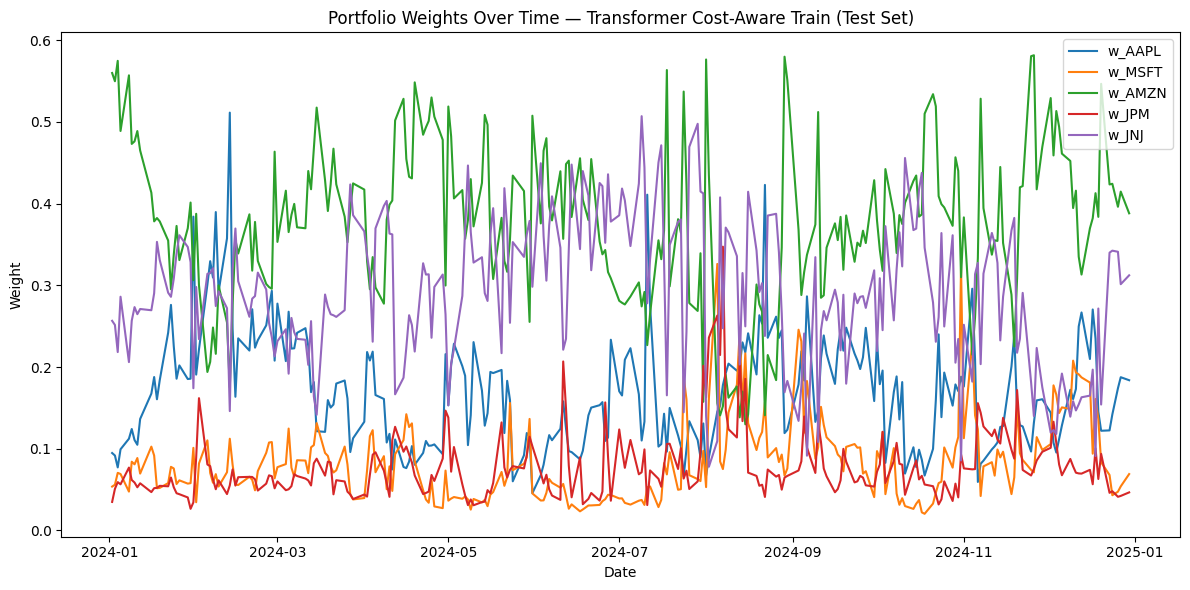

In [72]:
# ============================================================
# NEW CELL — Plot portfolio weights over time
# ============================================================

import matplotlib.pyplot as plt

plot_df = weights_cost_test.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df = plot_df.set_index("date")

weight_series = plot_df[["w_AAPL", "w_MSFT", "w_AMZN", "w_JPM", "w_JNJ"]]

plt.figure(figsize=(12, 6))
for col in weight_series.columns:
    plt.plot(weight_series.index, weight_series[col], label=col)

plt.title("Portfolio Weights Over Time — Transformer Cost-Aware Train (Test Set)")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
# ============================================================
# CELL 14 — Evaluate both models under frictionless no-cost evaluation
# ============================================================

frictionless_rows = []
frictionless_rollouts = {}

for model_name, model_obj in [
    ("Transformer_CostAwareTrain", cost_aware_model),
    ("Transformer_NoCostTrain", nocost_model),
]:
    frictionless_rollouts[model_name] = {}

    for split, X_split, y_split, d_split in [
        ("train", X_train, y_train, dates_train),
        ("val", X_val, y_val, dates_val),
        ("test", X_test, y_test, dates_test),
    ]:
        rollout_df, metrics = evaluate_policy(
            model=model_obj,
            X=X_split,
            y=y_split,
            dates=d_split,
            device=DEVICE,
            reward_mode="no_cost",
            transaction_cost=0.0,
        )
        frictionless_rollouts[model_name][split] = rollout_df
        frictionless_rows.append({
            "evaluation_mode": "no_cost_frictionless",
            "model": model_name,
            "split": split,
            **metrics,
        })

frictionless_df = pd.DataFrame(frictionless_rows)
display(frictionless_df)

,evaluation_mode,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,no_cost_frictionless,Transformer_CostAwareTrain,train,717,1.707442,0.707442,0.000896,0.017306,0.822063,-0.261326,0.310084,0.0,0.0
1,no_cost_frictionless,Transformer_CostAwareTrain,val,250,1.508407,0.508407,0.001702,0.010645,2.538067,-0.101523,0.231235,0.0,0.0
2,no_cost_frictionless,Transformer_CostAwareTrain,test,251,1.261468,0.261468,0.000974,0.009823,1.574676,-0.100794,0.216549,0.0,0.0
3,no_cost_frictionless,Transformer_NoCostTrain,train,717,2.095588,1.095588,0.001180,0.017239,1.086250,-0.190224,0.264390,0.0,0.0
4,no_cost_frictionless,Transformer_NoCostTrain,val,250,1.358669,0.358669,0.001268,0.009056,2.222228,-0.106751,0.188093,0.0,0.0
5,no_cost_frictionless,Transformer_NoCostTrain,test,251,1.244447,0.244447,0.000901,0.007652,1.869089,-0.058535,0.178987,0.0,0.0


In [74]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=frictionless_df)

https://docs.google.com/spreadsheets/d/13KKltDh7O3rIKmbBL8uQ5gYgUax0eEZ2NVMCFB815fo/edit#gid=0


In [75]:
# ============================================================
# CELL 15 — Combine reward comparison tables
# ============================================================

reward_comparison_df = pd.concat([realistic_df, frictionless_df], axis=0, ignore_index=True)
display(reward_comparison_df)

,evaluation_mode,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,cost_aware_realistic,Transformer_CostAwareTrain,train,717,1.366996,0.366996,0.000896,0.017306,0.822063,-0.277366,0.310084,0.222330,0.000310
1,cost_aware_realistic,Transformer_CostAwareTrain,val,250,1.423668,0.423668,0.001702,0.010645,2.538067,-0.113637,0.231235,0.057809,0.000231
2,cost_aware_realistic,Transformer_CostAwareTrain,test,251,1.194722,0.194722,0.000974,0.009823,1.574676,-0.105164,0.216549,0.054354,0.000217
3,cost_aware_realistic,Transformer_NoCostTrain,train,717,1.733650,0.733650,0.001180,0.017239,1.086250,-0.213309,0.264390,0.189568,0.000264
4,cost_aware_realistic,Transformer_NoCostTrain,val,250,1.296251,0.296251,0.001268,0.009056,2.222228,-0.116849,0.188093,0.047023,0.000188
5,cost_aware_realistic,Transformer_NoCostTrain,test,251,1.189770,0.189770,0.000901,0.007652,1.869089,-0.061448,0.178987,0.044926,0.000179
6,no_cost_frictionless,Transformer_CostAwareTrain,train,717,1.707442,0.707442,0.000896,0.017306,0.822063,-0.261326,0.310084,0.000000,0.000000
7,no_cost_frictionless,Transformer_CostAwareTrain,val,250,1.508407,0.508407,0.001702,0.010645,2.538067,-0.101523,0.231235,0.000000,0.000000
8,no_cost_frictionless,Transformer_CostAwareTrain,test,251,1.261468,0.261468,0.000974,0.009823,1.574676,-0.100794,0.216549,0.000000,0.000000
9,no_cost_frictionless,Transformer_NoCostTrain,train,717,2.095588,1.095588,0.001180,0.017239,1.086250,-0.190224,0.264390,0.000000,0.000000


In [76]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=reward_comparison_df)

https://docs.google.com/spreadsheets/d/1nQJ9dJgPeZp3QyczPo-pV13aJyIanDygtTbN4kQCF4w/edit#gid=0


In [77]:
# ============================================================
# CELL 16 — Focused test comparison table
# ============================================================

test_reward_table = reward_comparison_df[reward_comparison_df["split"] == "test"].copy()
test_reward_table.to_csv(f"{TAB_DIR}/reward_compare_5y.csv", index=False)
display(test_reward_table)

,evaluation_mode,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
2,cost_aware_realistic,Transformer_CostAwareTrain,test,251,1.194722,0.194722,0.000974,0.009823,1.574676,-0.105164,0.216549,0.054354,0.000217
5,cost_aware_realistic,Transformer_NoCostTrain,test,251,1.189770,0.189770,0.000901,0.007652,1.869089,-0.061448,0.178987,0.044926,0.000179
8,no_cost_frictionless,Transformer_CostAwareTrain,test,251,1.261468,0.261468,0.000974,0.009823,1.574676,-0.100794,0.216549,0.000000,0.000000
11,no_cost_frictionless,Transformer_NoCostTrain,test,251,1.244447,0.244447,0.000901,0.007652,1.869089,-0.058535,0.178987,0.000000,0.000000


In [78]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=test_reward_table)

https://docs.google.com/spreadsheets/d/18P0C6nGBrNW2UyYaHFJ5GeSo99PN8pB1lLJeXkMonhI/edit#gid=0


In [79]:
# ============================================================
# CELL 17 — Turnover comparison on test
# ============================================================

turnover_test = test_reward_table[[
    "evaluation_mode", "model", "avg_turnover", "total_trading_cost", "cumulative_return", "sharpe_approx"
]].copy()

display(turnover_test)

,evaluation_mode,model,avg_turnover,total_trading_cost,cumulative_return,sharpe_approx
2,cost_aware_realistic,Transformer_CostAwareTrain,0.216549,0.054354,0.194722,1.574676
5,cost_aware_realistic,Transformer_NoCostTrain,0.178987,0.044926,0.189770,1.869089
8,no_cost_frictionless,Transformer_CostAwareTrain,0.216549,0.000000,0.261468,1.574676
11,no_cost_frictionless,Transformer_NoCostTrain,0.178987,0.000000,0.244447,1.869089


In [80]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=turnover_test)

https://docs.google.com/spreadsheets/d/1bJdkPWBWKgO8h8w_y9C7Vi6INQlCBn4Tchhn6i6lIpE/edit#gid=0


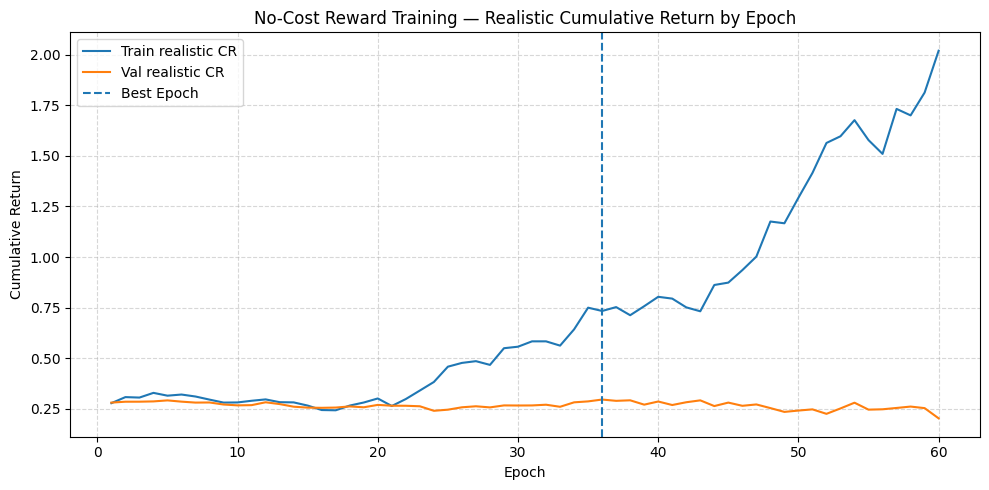

In [81]:
# ============================================================
# CELL 18 — Plot training curve for no-cost reward model
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(
    nocost_history_df["epoch"],
    nocost_history_df["train_cumulative_return_realistic"],
    label="Train realistic CR"
)
plt.plot(
    nocost_history_df["epoch"],
    nocost_history_df["val_cumulative_return_realistic"],
    label="Val realistic CR"
)
plt.axvline(nocost_best_epoch, linestyle="--", label="Best Epoch")
plt.title("No-Cost Reward Training — Realistic Cumulative Return by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cumulative Return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

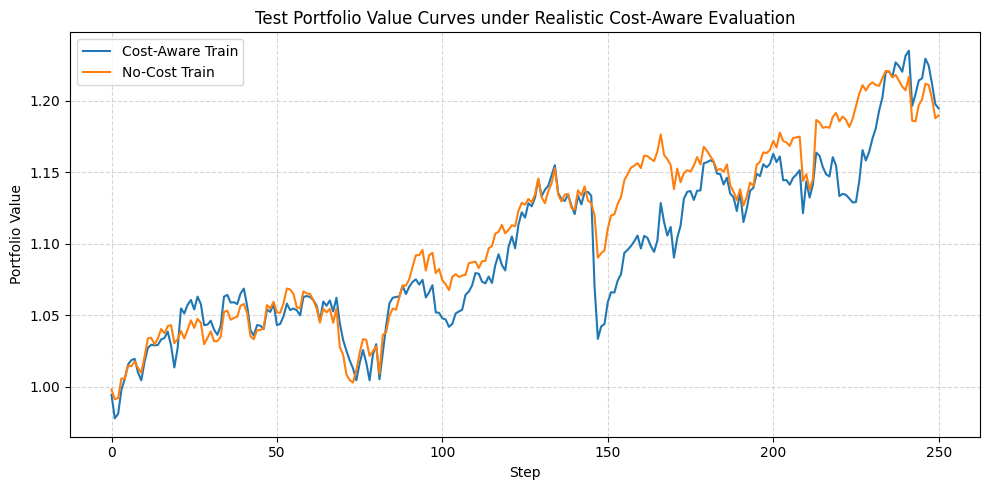

In [82]:
# ============================================================
# CELL 19 — Plot test portfolio value curves under realistic evaluation
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(
    realistic_rollouts["Transformer_CostAwareTrain"]["test"]["portfolio_value"].values,
    label="Cost-Aware Train"
)
plt.plot(
    realistic_rollouts["Transformer_NoCostTrain"]["test"]["portfolio_value"].values,
    label="No-Cost Train"
)
plt.title("Test Portfolio Value Curves under Realistic Cost-Aware Evaluation")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/reward_curves_5y.png", dpi=300, bbox_inches="tight")
plt.show()

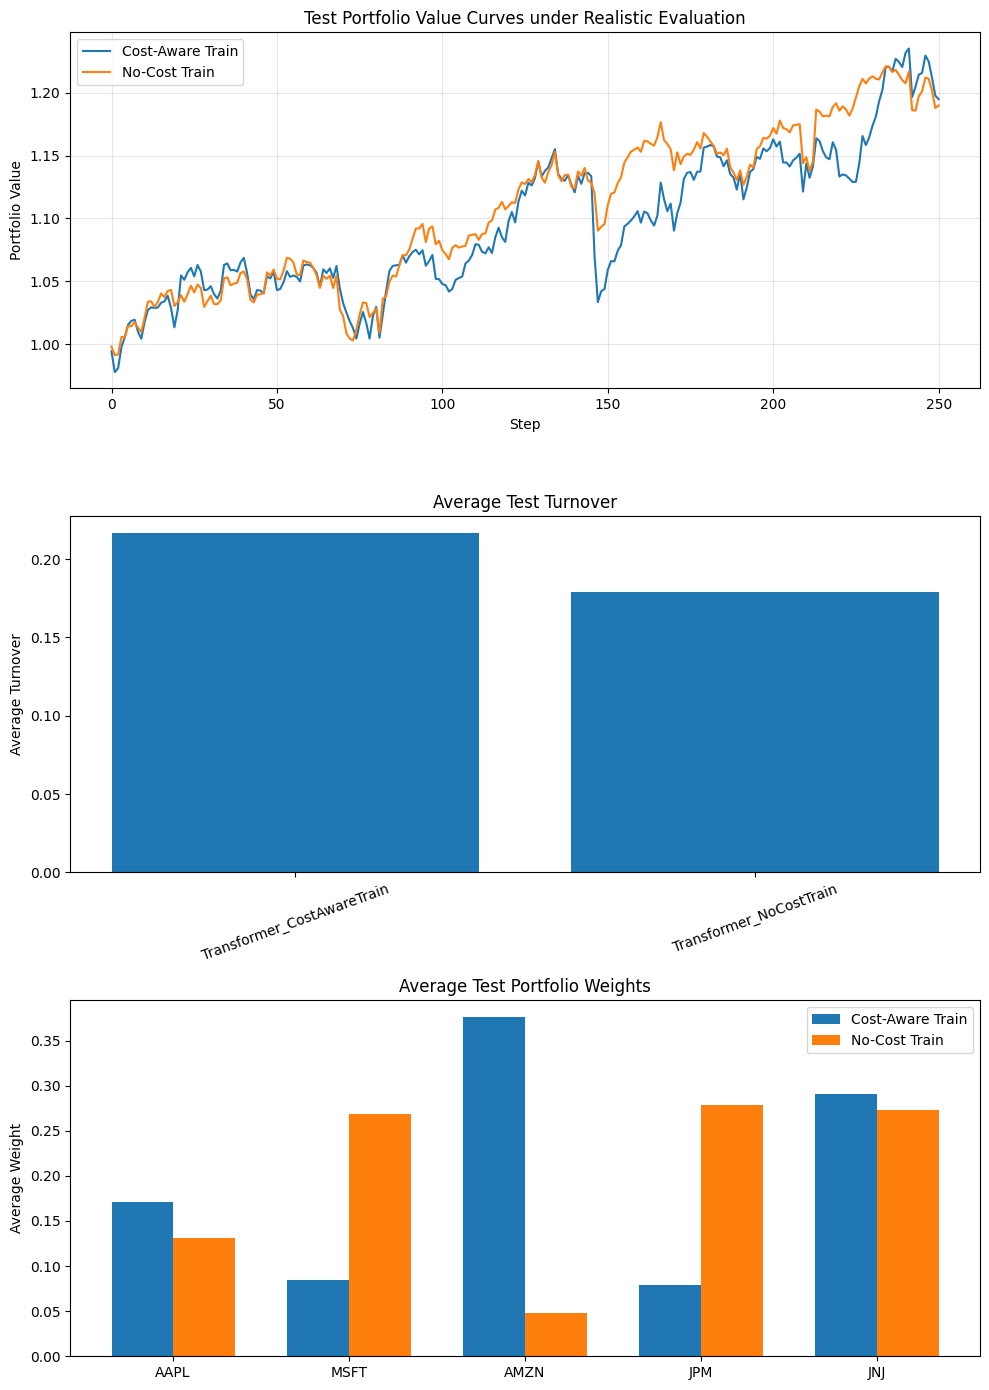

In [83]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define missing variables from the notebook state
test_steps = np.arange(len(realistic_rollouts["Transformer_CostAwareTrain"]["test"]))
cost_aware_curve = realistic_rollouts["Transformer_CostAwareTrain"]["test"]["portfolio_value"].values
no_cost_curve = realistic_rollouts["Transformer_NoCostTrain"]["test"]["portfolio_value"].values

cost_aware_turnover = turnover_test[turnover_test["model"] == "Transformer_CostAwareTrain"]["avg_turnover"].iloc[0]
no_cost_turnover = turnover_test[turnover_test["model"] == "Transformer_NoCostTrain"]["avg_turnover"].iloc[0]

asset_names = ASSETS # ASSETS is defined in Cell 03

# Code from Cell 21 (8t-bJaFFg_1w) to define avg_weights_df
def get_avg_weights(df_rollout: pd.DataFrame, assets: list) -> pd.Series:
    weight_cols = [f"w_{asset}" for asset in assets]
    return df_rollout[weight_cols].mean()

avg_w_cost = get_avg_weights(realistic_rollouts["Transformer_CostAwareTrain"]["test"], ASSETS)
avg_w_nocost = get_avg_weights(realistic_rollouts["Transformer_NoCostTrain"]["test"], ASSETS)

avg_weights_df = pd.DataFrame({
    "asset": ASSETS,
    "cost_aware_train": avg_w_cost.values,
    "no_cost_train": avg_w_nocost.values,
})

avg_w_cost_aware = avg_weights_df["cost_aware_train"].values
avg_w_no_cost = avg_weights_df["no_cost_train"].values

fig, axes = plt.subplots(3, 1, figsize=(10, 14))

# Panel 1: portfolio value curves
ax = axes[0]
ax.plot(test_steps, cost_aware_curve, label="Cost-Aware Train")
ax.plot(test_steps, no_cost_curve, label="No-Cost Train")
ax.set_title("Test Portfolio Value Curves under Realistic Evaluation")
ax.set_xlabel("Step")
ax.set_ylabel("Portfolio Value")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: turnover comparison
ax = axes[1]
labels = ["Transformer_CostAwareTrain", "Transformer_NoCostTrain"]
turnovers = [cost_aware_turnover, no_cost_turnover]
ax.bar(labels, turnovers)
ax.set_title("Average Test Turnover")
ax.set_ylabel("Average Turnover")
ax.tick_params(axis='x', rotation=20)

# Panel 3: average weights
ax = axes[2]
x = np.arange(len(asset_names))
width = 0.35
ax.bar(x - width/2, avg_w_cost_aware, width, label="Cost-Aware Train")
ax.bar(x + width/2, avg_w_no_cost, width, label="No-Cost Train")
ax.set_title("Average Test Portfolio Weights")
ax.set_xticks(x)
ax.set_xticklabels(asset_names)
ax.set_ylabel("Average Weight")
ax.legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/reward_overview_5y.png", dpi=300, bbox_inches="tight")
plt.show()

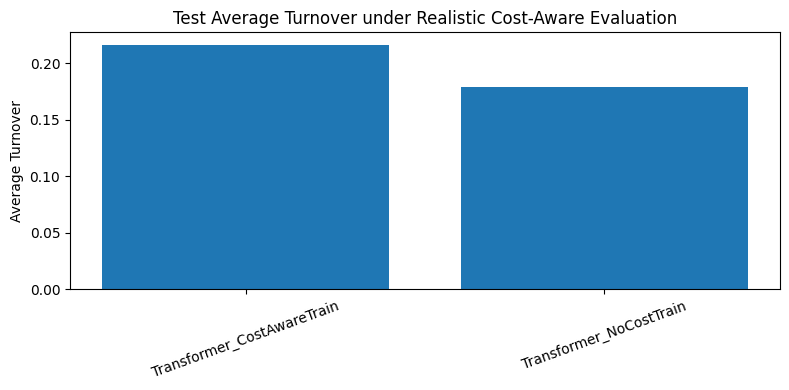

In [84]:
# ============================================================
# CELL 20 — Plot test turnover comparison
# ============================================================

plot_df = realistic_df[realistic_df["split"] == "test"].copy()

plt.figure(figsize=(8, 4))
plt.bar(plot_df["model"], plot_df["avg_turnover"])
plt.title("Test Average Turnover under Realistic Cost-Aware Evaluation")
plt.ylabel("Average Turnover")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/reward_turnover_5y.png", dpi=300, bbox_inches="tight")
plt.show()

,asset,cost_aware_train,no_cost_train
0,AAPL,0.170605,0.131521
1,MSFT,0.084288,0.268825
2,AMZN,0.375767,0.048404
3,JPM,0.078450,0.278143
4,JNJ,0.290890,0.273109


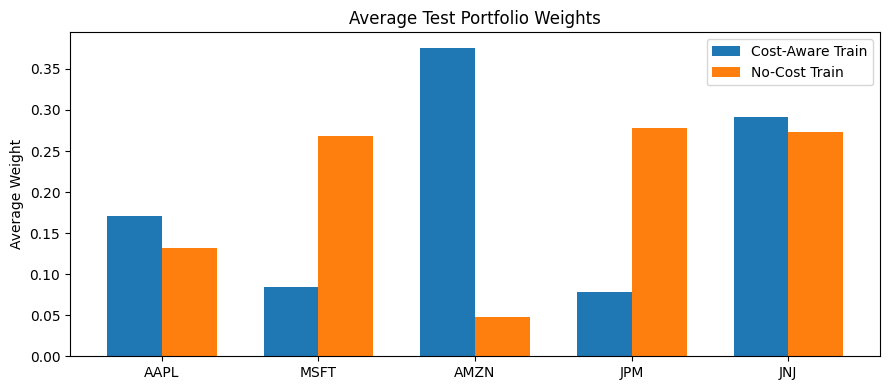

In [85]:
# ============================================================
# CELL 21 — Plot average test weights
# ============================================================

def get_avg_weights(df_rollout: pd.DataFrame, assets: list) -> pd.Series:
    weight_cols = [f"w_{asset}" for asset in assets]
    return df_rollout[weight_cols].mean()

avg_w_cost = get_avg_weights(realistic_rollouts["Transformer_CostAwareTrain"]["test"], ASSETS)
avg_w_nocost = get_avg_weights(realistic_rollouts["Transformer_NoCostTrain"]["test"], ASSETS)

avg_weights_df = pd.DataFrame({
    "asset": ASSETS,
    "cost_aware_train": avg_w_cost.values,
    "no_cost_train": avg_w_nocost.values,
})

display(avg_weights_df)

x = np.arange(len(ASSETS))
width = 0.35

plt.figure(figsize=(9, 4))
plt.bar(x - width/2, avg_weights_df["cost_aware_train"], width=width, label="Cost-Aware Train")
plt.bar(x + width/2, avg_weights_df["no_cost_train"], width=width, label="No-Cost Train")
plt.xticks(x, ASSETS)
plt.ylabel("Average Weight")
plt.title("Average Test Portfolio Weights")
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=avg_weights_df)

https://docs.google.com/spreadsheets/d/1R8WcVHTdL6rycSGxgQr5p0W6LmatZVZsTZPQLPaEwRw/edit#gid=0


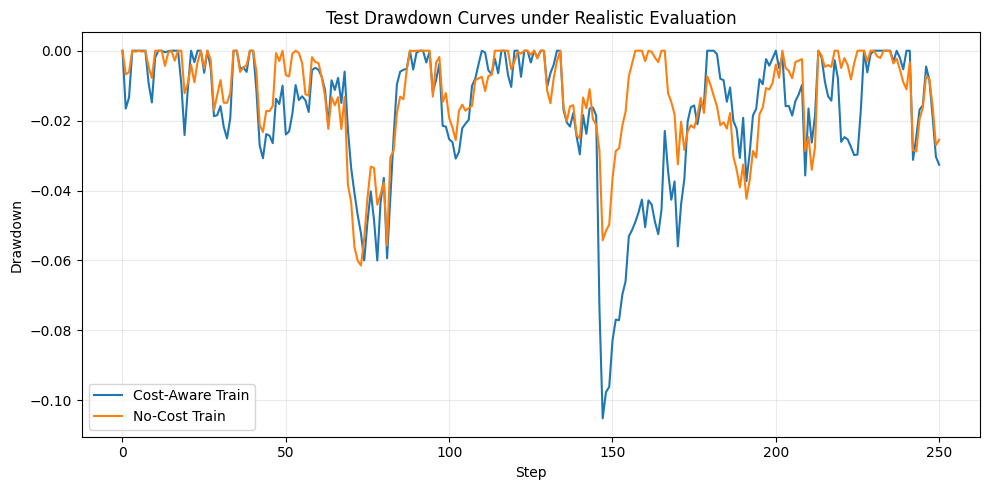

In [87]:
def compute_drawdown(series):
    s = pd.Series(series).astype(float)
    running_max = s.cummax()
    drawdown = s / running_max - 1.0
    return drawdown

dd_cost = compute_drawdown(cost_aware_curve)
dd_nocost = compute_drawdown(no_cost_curve)

plt.figure(figsize=(10, 5))
plt.plot(dd_cost.index, dd_cost.values, label="Cost-Aware Train")
plt.plot(dd_nocost.index, dd_nocost.values, label="No-Cost Train")
plt.title("Test Drawdown Curves under Realistic Evaluation")
plt.xlabel("Step")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/reward_drawdown_curves_5y.png", dpi=300, bbox_inches="tight")
plt.show()

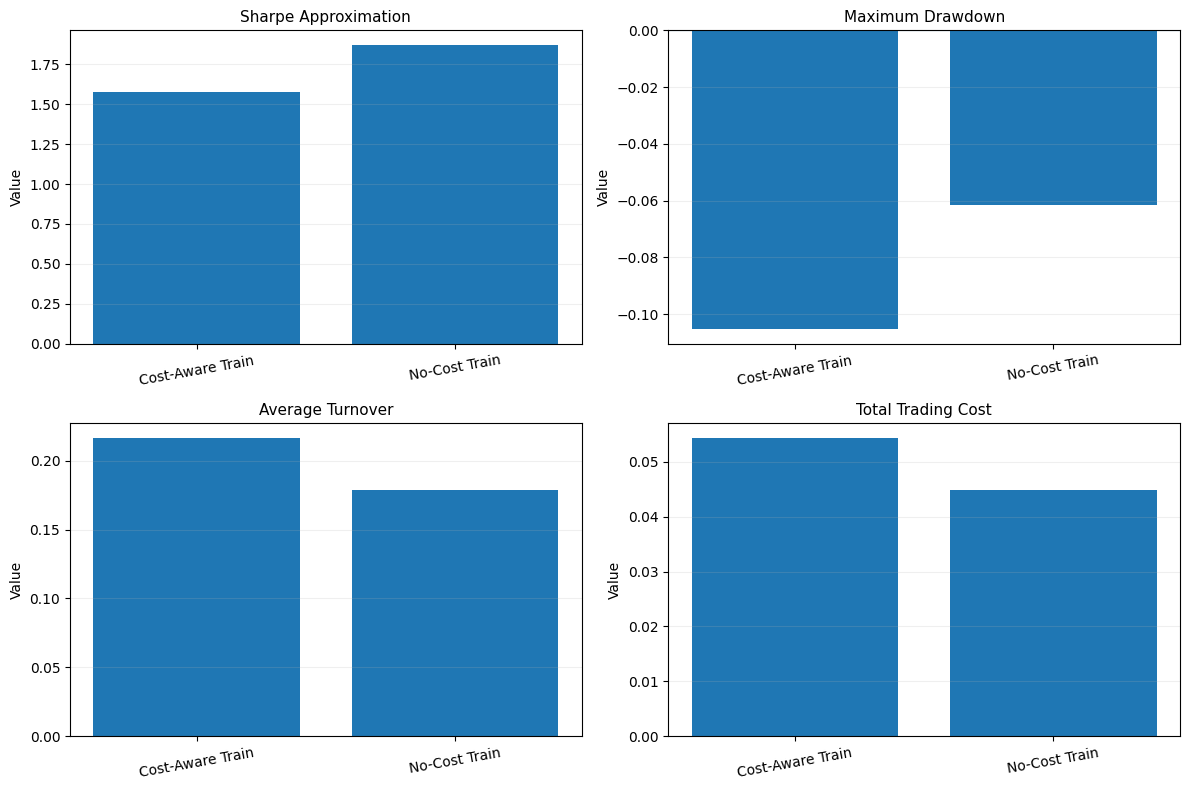

In [88]:
cost_aware_metrics = test_reward_table[
    (test_reward_table["model"] == "Transformer_CostAwareTrain") &
    (test_reward_table["evaluation_mode"] == "cost_aware_realistic")
].iloc[0]

nocost_metrics = test_reward_table[
    (test_reward_table["model"] == "Transformer_NoCostTrain") &
    (test_reward_table["evaluation_mode"] == "cost_aware_realistic")
].iloc[0]

df_metrics_rq2 = pd.DataFrame({
    "Variant": ["Cost-Aware Train", "No-Cost Train"],
    "Sharpe Approximation": [cost_aware_metrics["sharpe_approx"], nocost_metrics["sharpe_approx"]],
    "Maximum Drawdown": [cost_aware_metrics["max_drawdown"], nocost_metrics["max_drawdown"]],
    "Average Turnover": [cost_aware_metrics["avg_turnover"], nocost_metrics["avg_turnover"]],
    "Total Trading Cost": [cost_aware_metrics["total_trading_cost"], nocost_metrics["total_trading_cost"]],
})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

metric_names = [
    "Sharpe Approximation",
    "Maximum Drawdown",
    "Average Turnover",
    "Total Trading Cost",
]

for ax, metric in zip(axes, metric_names):
    values = df_metrics_rq2[metric].values
    labels = df_metrics_rq2["Variant"].values
    ax.bar(labels, values)

    ax.set_title(metric, fontsize=11)
    ax.set_ylabel("Value")
    ax.tick_params(axis="x", rotation=10)
    ax.grid(axis="y", alpha=0.2)

    if metric == "Maximum Drawdown":
        ax.axhline(0, linewidth=0.8)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/reward_metrics_4panel_5y.png", dpi=300, bbox_inches="tight")
plt.show()

In [89]:
# ============================================================
# CELL 22 — Save reward comparison outputs
# ============================================================

reward_comparison_df.to_csv(f"{OUTPUTS_REWARD_DIR}/reward_comparison_all_5y.csv", index=False)
realistic_df.to_csv(f"{OUTPUTS_REWARD_DIR}/reward_comparison_realistic_5y.csv", index=False)
frictionless_df.to_csv(f"{OUTPUTS_REWARD_DIR}/reward_comparison_frictionless_5y.csv", index=False)
test_reward_table.to_csv(f"{OUTPUTS_REWARD_DIR}/reward_comparison_test_5y.csv", index=False)
avg_weights_df.to_csv(f"{OUTPUTS_REWARD_DIR}/reward_comparison_avg_test_weights_5y.csv", index=False)

realistic_rollouts["Transformer_CostAwareTrain"]["test"].to_csv(
    f"{OUTPUTS_REWARD_DIR}/costaware_train_test_rollout_realistic_5y.csv", index=False
)
realistic_rollouts["Transformer_NoCostTrain"]["test"].to_csv(
    f"{OUTPUTS_REWARD_DIR}/nocost_train_test_rollout_realistic_5y.csv", index=False
)

print("Saved reward comparison outputs.")

Saved reward comparison outputs.


In [90]:
# ============================================================
# CELL 23 — Final sanity checks
# ============================================================

required_files = [
    f"{OUTPUTS_REWARD_DIR}/reward_comparison_all_5y.csv",
    f"{OUTPUTS_REWARD_DIR}/reward_comparison_realistic_5y.csv",
    f"{OUTPUTS_REWARD_DIR}/reward_comparison_frictionless_5y.csv",
    f"{OUTPUTS_REWARD_DIR}/reward_comparison_test_5y.csv",
]

for fp in required_files:
    assert os.path.exists(fp), f"Missing file: {fp}"

assert len(realistic_df) == 6
assert len(frictionless_df) == 6

print("All reward comparison notebook checks passed.")

All reward comparison notebook checks passed.
